In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np


dataset, info = tfds.load('oxford_iiit_pet:4.0.0', with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.5JONX8_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.5JONX8_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


Calcul des snapshots...
Fait.
  Dice           : 0.8459
  IoU            : 0.7329
  Hausdorff (px) : 30.25


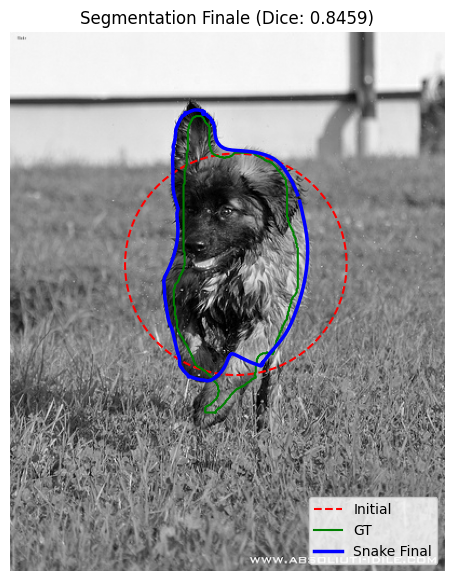

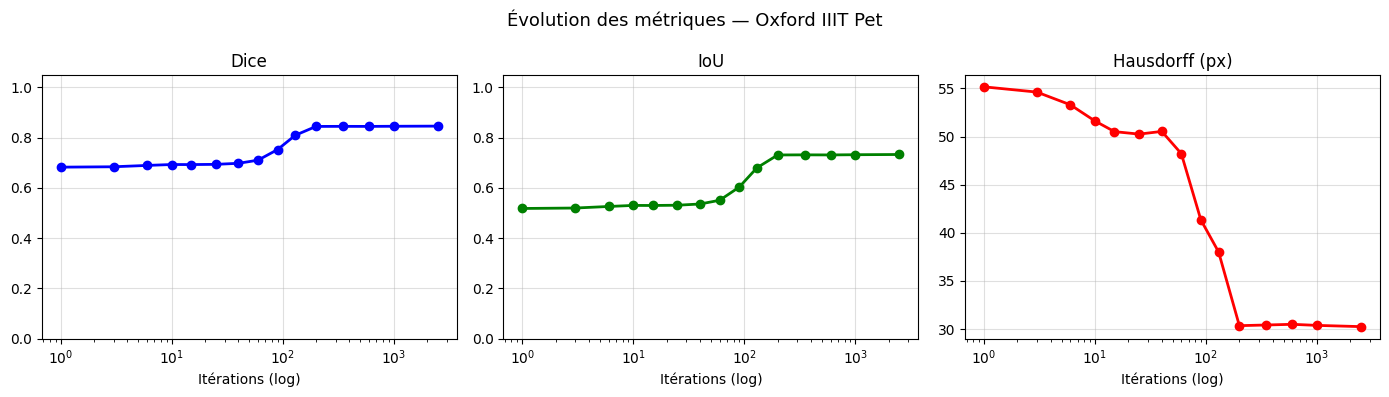

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage.filters import gaussian
from skimage.segmentation import active_contour
from skimage.draw import polygon
from skimage import measure
from scipy.spatial.distance import directed_hausdorff

# ── Récupération d'un échantillon ──────────────────────────────────────────
for sample in dataset['test'].take(1):
    img_tf  = sample['image']
    mask_tf = sample['segmentation_mask']

img_np  = img_tf.numpy().astype(np.float32) / 255.0
mask_np = mask_tf.numpy().squeeze()

# label 1 = animal (ground truth)
mask_gt = (mask_np == 1)

# ── Prétraitement ──────────────────────────────────────────────────────────
img_gray   = rgb2gray(img_np)
img_smooth = gaussian(img_gray, sigma=3, preserve_range=False)

# ── Initialisation autour du centroïde du masque GT ───────────────────────
rows, cols = np.where(mask_gt)
r_c    = (rows.min() + rows.max()) / 2
c_c    = (cols.min() + cols.max()) / 2
radius = max(rows.max() - rows.min(),
             cols.max() - cols.min()) / 2 * 0.75

s    = np.linspace(0, 2 * np.pi, 400)
init = np.array([r_c + radius * np.sin(s),
                 c_c + radius * np.cos(s)]).T
init[:, 0] = np.clip(init[:, 0], 1, img_gray.shape[0] - 2)
init[:, 1] = np.clip(init[:, 1], 1, img_gray.shape[1] - 2)

# ── Snapshots ──────────────────────────────────────────────────────────────
# ── Prétraitement optimisé ──────────────────────────────────────────────────
# Un floutage légèrement plus fort aide à effacer les brins d'herbe qui piègent le snake
img_smooth = gaussian(img_gray, sigma=4, preserve_range=False)

# ── Snapshots avec nouveaux paramètres ──────────────────────────────────────
iter_steps = [1, 3, 6, 10, 15, 25, 40, 60, 90, 130, 200, 350, 600, 1000, 2500]
print("Calcul des snapshots...")
snapshots = [
    active_contour(
        img_smooth,
        init.copy(),
        alpha=0.01,
        beta=0.1,
        gamma=0.001,
        w_line=0,
        w_edge=5,
        max_num_iter=n
    )
    for n in iter_steps
]
print("Fait.")

# ── Métriques ──────────────────────────────────────────────────────────────
def contour_to_mask(contour, shape):
    mask = np.zeros(shape, dtype=bool)
    rr, cc = polygon(contour[:, 0], contour[:, 1], shape)
    mask[rr, cc] = True
    return mask

def dice_score(pred, gt):
    inter = np.logical_and(pred, gt).sum()
    return 2 * inter / (pred.sum() + gt.sum() + 1e-8)

def iou_score(pred, gt):
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return inter / (union + 1e-8)

def hausdorff_dist(c_pred, c_gt):
    return max(directed_hausdorff(c_pred, c_gt)[0],
               directed_hausdorff(c_gt, c_pred)[0])

# Contour GT extrait du masque binaire
contours_gt = measure.find_contours(mask_gt.astype(float), 0.5)
gt_contour  = max(contours_gt, key=len)

# Calcul pour chaque snapshot
dice_vals, iou_vals, haus_vals = [], [], []
for snap in snapshots:
    m = contour_to_mask(snap, img_gray.shape)
    dice_vals.append(dice_score(m, mask_gt))
    iou_vals.append(iou_score(m, mask_gt))
    haus_vals.append(hausdorff_dist(snap, gt_contour))

# Résultats finaux console
final      = snapshots[-1]
mask_final = contour_to_mask(final, img_gray.shape)
print("=" * 45)
print(f"  Dice           : {dice_score(mask_final, mask_gt):.4f}")
print(f"  IoU            : {iou_score(mask_final, mask_gt):.4f}")
print(f"  Hausdorff (px) : {hausdorff_dist(final, gt_contour):.2f}")
print("=" * 45)

# ── Animation (FIX : plt.ion + boucle manuelle) ───────────────────────────
# ── Visualisation Fixe Finale (Spécial Colab) ──────────────────────────────
fig_final, ax_final = plt.subplots(figsize=(7, 7))
ax_final.imshow(img_gray, cmap='gray')
ax_final.plot(init[:, 1], init[:, 0], '--r', lw=1.5, label='Initial')
ax_final.plot(gt_contour[:, 1], gt_contour[:, 0], '-g', lw=1.5, label='GT')
ax_final.plot(snapshots[-1][:, 1], snapshots[-1][:, 0], '-b', lw=2.5, label='Snake Final')
ax_final.set_title(f"Segmentation Finale (Dice: {dice_score(mask_final, mask_gt):.4f})")
ax_final.legend(loc='lower right')
ax_final.axis('off')
plt.show()

# ── Figure 2 : Évolution des métriques ────────────────────────────────────
fig2, axes = plt.subplots(1, 3, figsize=(14, 4))
fig2.suptitle("Évolution des métriques — Oxford IIIT Pet", fontsize=13)

for ax_, vals, label, color in zip(
        axes,
        [dice_vals, iou_vals, haus_vals],
        ["Dice", "IoU", "Hausdorff (px)"],
        ['b', 'g', 'r']):
    ax_.plot(iter_steps, vals, f'o-{color}', lw=2)
    ax_.set_title(label)
    ax_.set_xlabel("Itérations (log)")
    ax_.set_xscale('log')
    ax_.grid(alpha=0.4)
    if label != "Hausdorff (px)":
        ax_.set_ylim(0, 1.05)

plt.tight_layout()
plt.show(block=True)

In [3]:
# ── CONFIGURATION ET FONCTION POUR L'ÉVALUATION RAPIDE ─────────────────────
IMG_SIZE = 128
train_data = dataset['train']

def run_snake_fast(img_np):
    img_gray = rgb2gray(img_np)

    # Prétraitement : lissage adapté pour le format 128x128
    img_smooth = gaussian(img_gray, sigma=3, preserve_range=False)

    # Initialisation du cercle centré (Format 128x128)
    r_c, c_c = IMG_SIZE / 2, IMG_SIZE / 2

    # ── MODIFICATION DE LA TAILLE DU CERCLE ICI ───────────────────────────
    radius = (IMG_SIZE / 2) * 0.75
    # ──────────────────────────────────────────────────────────────────────

    s = np.linspace(0, 2 * np.pi, 400)
    init = np.array([r_c + radius * np.sin(s), c_c + radius * np.cos(s)]).T
    init[:, 0] = np.clip(init[:, 0], 1, IMG_SIZE - 2)
    init[:, 1] = np.clip(init[:, 1], 1, IMG_SIZE - 2)

    # Exécution du Snake (limité à 400 itérations pour que ça reste rapide)
    snap = active_contour(img_smooth, init,
                          alpha=0.005, beta=0.001, gamma=0.01,
                          max_num_iter=400)

    return contour_to_mask(snap, img_gray.shape)

def preprocess_for_eval(sample):
    # Redimensionnement des images en 128x128 comme Chan-Vese
    image = tf.image.resize(sample["image"], (IMG_SIZE, IMG_SIZE))
    mask = tf.image.resize(sample["segmentation_mask"], (IMG_SIZE, IMG_SIZE), method='nearest')

    image = tf.cast(image, tf.float32) / 255.0
    mask_gt = tf.cast((mask == 1), tf.float32).numpy().squeeze()

    return image.numpy(), mask_gt


VÉRIFICATION VISUELLE SUR LES 5 PREMIÈRES IMAGES


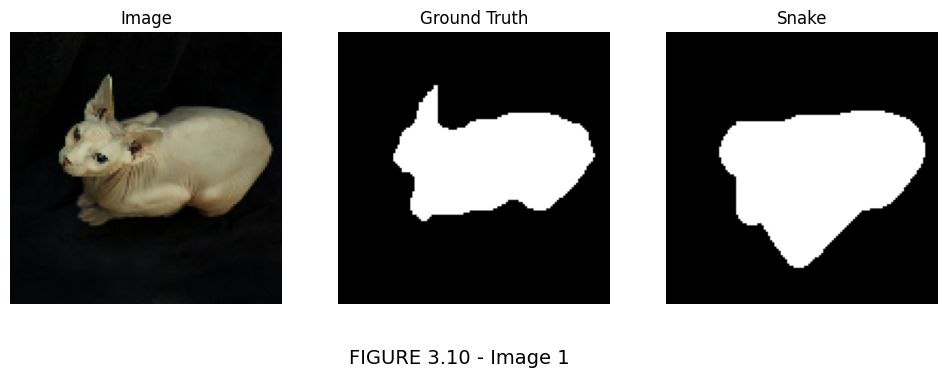

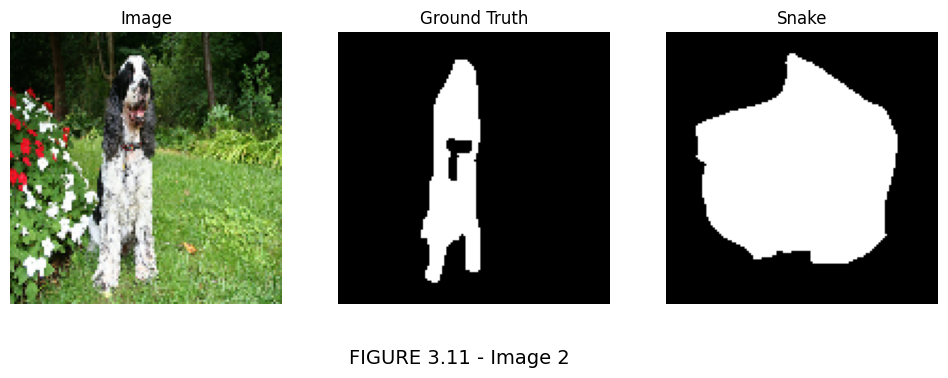

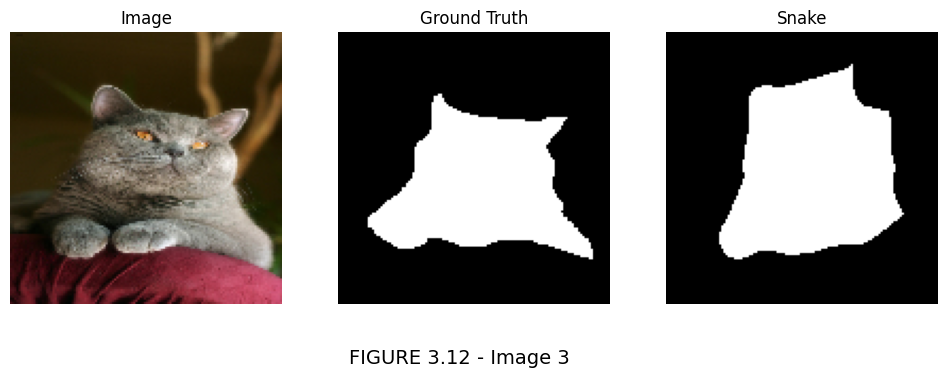

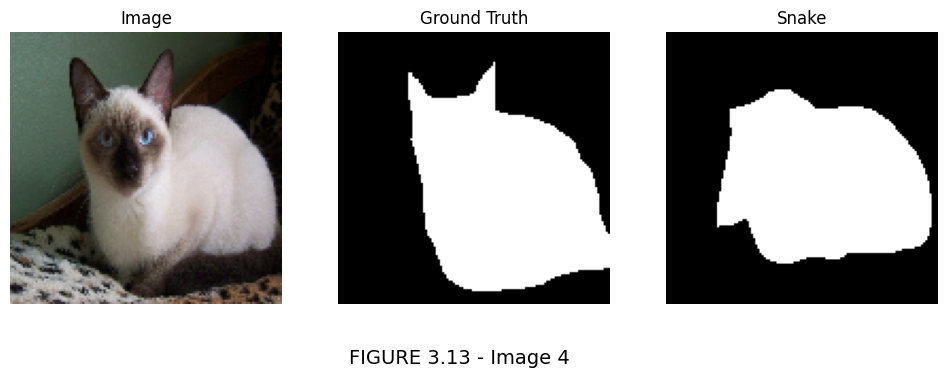

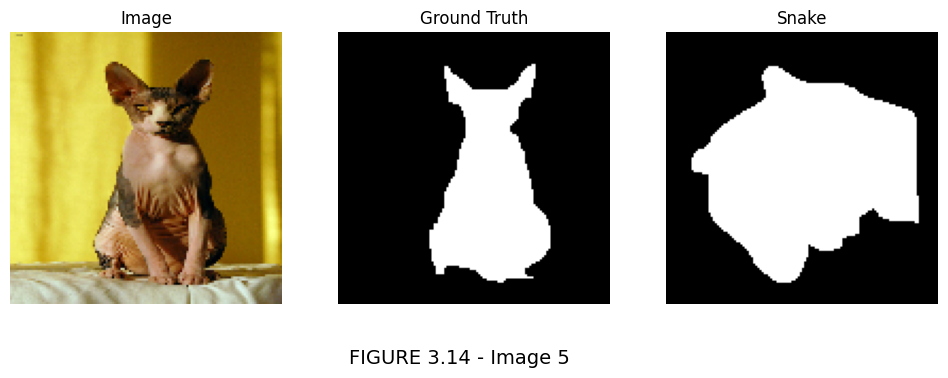

In [4]:
# ── AFFICHAGE DES 5 PREMIÈRES IMAGES (Pour le rapport) ─────────────────────
print("\n" + "="*50)
print("VÉRIFICATION VISUELLE SUR LES 5 PREMIÈRES IMAGES")
print("="*50)

# On prend les 5 premières images du dataset d'entraînement
for i, sample in enumerate(train_data.take(5)):
    # 1. Prétraitement
    img, gt = preprocess_for_eval(sample)

    # 2. Prédiction avec le modèle Snake
    pred_mask = run_snake_fast(img)

    # 3. Création de la figure (Format 1x3 comme ton amie)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # --- Panel 1 : Image originale ---
    axes[0].imshow(img)
    axes[0].set_title("Image")
    axes[0].axis("off")

    # --- Panel 2 : Ground Truth ---
    axes[1].imshow(gt, cmap="gray")
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    # --- Panel 3 : Résultat Snake ---
    axes[2].imshow(pred_mask, cmap="gray")
    axes[2].set_title("Snake")
    axes[2].axis("off")

    # Ajout du titre en bas pour correspondre aux légendes de son rapport
    fig.text(0.5, 0.05, f"FIGURE 3.{10+i} - Image {i+1}", ha='center', fontsize=14)

    plt.subplots_adjust(bottom=0.2) # Laisse de la place pour le texte en bas
    plt.show()

In [38]:
# ── ÉVALUATION SUR 50 IMAGES (Comparaison avec Chan-Vese) ─────────────────
print("\n" + "="*50)
print("DÉBUT DE L'ÉVALUATION SUR 50 IMAGES (Format 128x128)")
print("="*50)

IMG_SIZE = 128
train_data = dataset['train']

def preprocess_for_eval(sample):
    # Redimensionnement identique à Chan-Vese
    image = tf.image.resize(sample["image"], (IMG_SIZE, IMG_SIZE))
    mask = tf.image.resize(
        sample["segmentation_mask"],
        (IMG_SIZE, IMG_SIZE),
        method='nearest'
    )

    image = tf.cast(image, tf.float32) / 255.0

    # Classe 1 = animal
    mask_gt = tf.cast((mask == 1), tf.float32).numpy().squeeze()

    return image.numpy(), mask_gt


def run_snake_fast(img_np):
    img_gray = rgb2gray(img_np)

    # Prétraitement
    img_smooth = gaussian(img_gray, sigma=3, preserve_range=False)

    # Initialisation cercle centré
    r_c, c_c = IMG_SIZE / 2, IMG_SIZE / 2
    radius = (IMG_SIZE / 2) * 0.7

    s = np.linspace(0, 2 * np.pi, 400)

    init = np.array([
        r_c + radius * np.sin(s),
        c_c + radius * np.cos(s)
    ]).T

    init[:, 0] = np.clip(init[:, 0], 1, IMG_SIZE - 2)
    init[:, 1] = np.clip(init[:, 1], 1, IMG_SIZE - 2)

    # Snake
    snap = active_contour(
        img_smooth,
        init,
        alpha=0.01,
        beta=0.1,
        gamma=0.001,
        w_line=0,
        w_edge=5,
        max_num_iter=400
    )

    return contour_to_mask(snap, img_gray.shape)


# ── Évaluation ──────────────────────────────────────────────────────────────
results_eval = []

print("Calcul en cours sur 50 images...")

for i, sample in enumerate(train_data.take(50)):

    # Prétraitement
    img, gt = preprocess_for_eval(sample)

    # Prédiction
    pred_mask = run_snake_fast(img)

    # ── Dice / IoU ─────────────────────────────────────────────────────────
    d = dice_score(pred_mask, gt)
    j = iou_score(pred_mask, gt)

    # ── Hausdorff normalisé ────────────────────────────────────────────────
    contours_gt = measure.find_contours(gt.astype(float), 0.5)
    gt_contour = max(contours_gt, key=len)

    contours_pred = measure.find_contours(pred_mask.astype(float), 0.5)

    if len(contours_pred) > 0:
        pred_contour = max(contours_pred, key=len)

        haus = hausdorff_dist(pred_contour, gt_contour)

        diag = np.sqrt(
            pred_mask.shape[0]**2 +
            pred_mask.shape[1]**2
        )

        haus_norm = haus / diag

    else:
        haus_norm = 1.0

    # Sauvegarde
    results_eval.append((d, j, haus_norm))

    if (i + 1) % 10 == 0:
        print(f" -> Images traitées : {i+1}/50")


# ── Moyennes finales ───────────────────────────────────────────────────────
dice_mean = np.mean([r[0] for r in results_eval])
iou_mean = np.mean([r[1] for r in results_eval])
haus_mean = np.mean([r[2] for r in results_eval])

# ── Résultats ──────────────────────────────────────────────────────────────
print("\n" + "-" * 50)
print("RÉSULTATS FINAUX SUR 50 IMAGES (SNAKE)")
print(f"Dice moyen                : {dice_mean:.4f}")
print(f"IoU moyen                 : {iou_mean:.4f}")
print(f"Hausdorff normalisé moyen : {haus_mean:.4f}")
print("-" * 50)


DÉBUT DE L'ÉVALUATION SUR 50 IMAGES (Format 128x128)
Calcul en cours sur 50 images...
 -> Images traitées : 10/50
 -> Images traitées : 20/50
 -> Images traitées : 30/50
 -> Images traitées : 40/50
 -> Images traitées : 50/50

--------------------------------------------------
RÉSULTATS FINAUX SUR 50 IMAGES (SNAKE)
Dice moyen                : 0.6512
IoU moyen                 : 0.5036
Hausdorff normalisé moyen : 0.1965
--------------------------------------------------


Résultats sur la 1ère image
Dice                 : 0.9111
IoU                  : 0.8368
Hausdorff normalisé  : 0.0692


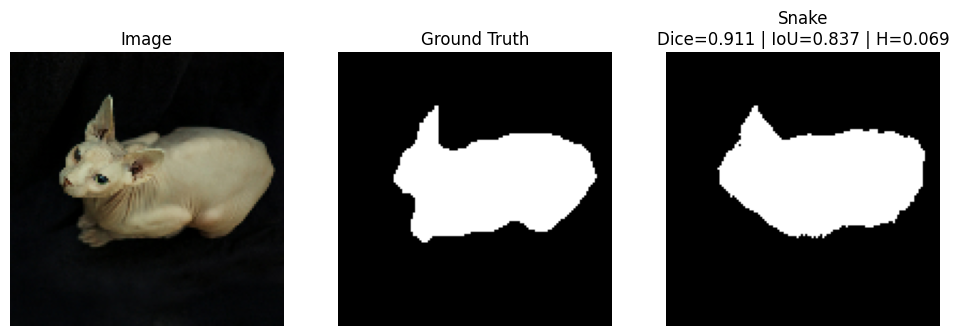

In [37]:
# ── TEST SUR LA PREMIÈRE IMAGE ─────────────────────────────────────────────
sample = next(iter(train_data.take(1)))

# Prétraitement
img, gt = preprocess_for_eval(sample)

# Prédiction Snake
pred_mask = run_snake_fast(img)

# ── Calcul Dice / IoU ──────────────────────────────────────────────────────
dice = dice_score(pred_mask, gt)
iou  = iou_score(pred_mask, gt)

# ── Calcul Hausdorff normalisé ─────────────────────────────────────────────
img_gray = rgb2gray(img)

# Contour Ground Truth
contours_gt = measure.find_contours(gt.astype(float), 0.5)
gt_contour = max(contours_gt, key=len)

# Contour prédit
contours_pred = measure.find_contours(pred_mask.astype(float), 0.5)
pred_contour = max(contours_pred, key=len)

# Hausdorff brut
haus = hausdorff_dist(pred_contour, gt_contour)

# Normalisation par la diagonale
diag = np.sqrt(img_gray.shape[0]**2 + img_gray.shape[1]**2)
haus_norm = haus / diag

# ── Affichage console ──────────────────────────────────────────────────────
print("=" * 50)
print("Résultats sur la 1ère image")
print(f"Dice                 : {dice:.4f}")
print(f"IoU                  : {iou:.4f}")
print(f"Hausdorff normalisé  : {haus_norm:.4f}")
print("=" * 50)

# ── Affichage visuel ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Image originale
axes[0].imshow(img)
axes[0].set_title("Image")
axes[0].axis("off")

# Ground Truth
axes[1].imshow(gt, cmap='gray')
axes[1].set_title("Ground Truth")
axes[1].axis("off")

# Prédiction Snake
axes[2].imshow(pred_mask, cmap='gray')
axes[2].set_title(
    f"Snake\nDice={dice:.3f} | IoU={iou:.3f} | H={haus_norm:.3f}"
)
axes[2].axis("off")

plt.show()

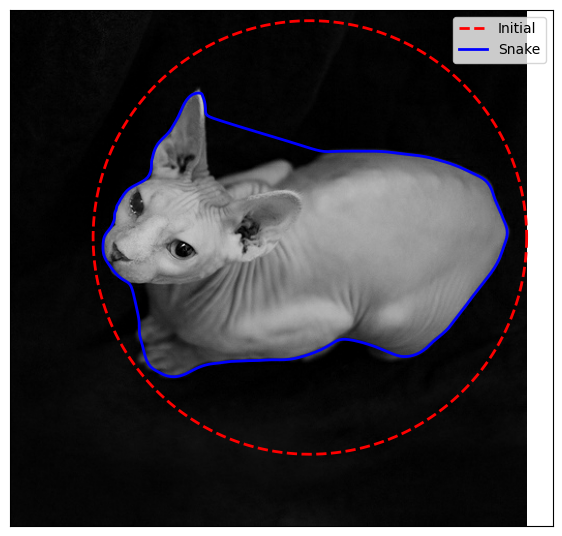

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage.filters import gaussian
from skimage.segmentation import active_contour

# ── Récupération de la 1ère image ──────────────────────────────────────────
for sample in train_data.take(1):
    img_tf = sample['image']

# Conversion NumPy + normalisation
img = img_tf.numpy().astype(np.float32) / 255.0

# Passage en niveaux de gris
img_gray = rgb2gray(img)

# ── Initialisation du contour ──────────────────────────────────────────────
s = np.linspace(0, 2 * np.pi, 400)

r = 220 + 210 * np.sin(s)
c = 290 + 210 * np.cos(s)

init = np.array([r, c]).T

# ── Active Contour (Snake) ─────────────────────────────────────────────────
snake = active_contour(
    gaussian(img_gray, sigma=3, preserve_range=False),
    init,
    alpha=0.01,
    beta=0.01,
    gamma=0.001,

)

# ── Affichage ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(img_gray, cmap='gray')

# Contour initial
ax.plot(init[:, 1], init[:, 0], '--r', lw=2, label='Initial')

# Snake final
ax.plot(snake[:, 1], snake[:, 0], '-b', lw=2, label='Snake')

ax.set_xticks([])
ax.set_yticks([])
ax.legend()

plt.show()

Dice : 0.8804
IoU  : 0.7864


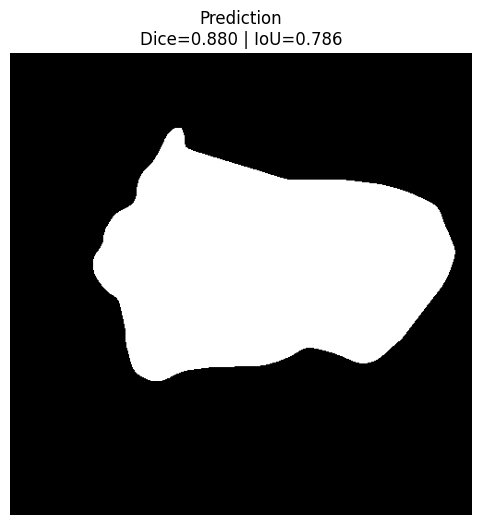

In [34]:
from skimage.draw import polygon
from skimage import measure

# ── Ground Truth ───────────────────────────────────────────────────────────
for sample in train_data.take(1):
    mask_tf = sample['segmentation_mask']

mask = mask_tf.numpy().squeeze()

# Classe 1 = animal
gt = (mask == 1)

# ── Conversion du snake en masque binaire ──────────────────────────────────
pred_mask = np.zeros(img_gray.shape, dtype=bool)

rr, cc = polygon(snake[:, 0], snake[:, 1], img_gray.shape)
pred_mask[rr, cc] = True

# ── Métriques ──────────────────────────────────────────────────────────────
def dice_score(pred, gt):
    inter = np.logical_and(pred, gt).sum()
    return 2 * inter / (pred.sum() + gt.sum() + 1e-8)

def iou_score(pred, gt):
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return inter / (union + 1e-8)

dice = dice_score(pred_mask, gt)
iou  = iou_score(pred_mask, gt)

print("=" * 40)
print(f"Dice : {dice:.4f}")
print(f"IoU  : {iou:.4f}")
print("=" * 40)
plt.figure(figsize=(6,6))
plt.imshow(pred_mask, cmap='gray')
plt.title(f"Prediction\nDice={dice:.3f} | IoU={iou:.3f}")
plt.axis('off')
plt.show()


In [36]:
haus = hausdorff_dist(snake, gt_contour)

# Diagonale image
diag = np.sqrt(img_gray.shape[0]**2 + img_gray.shape[1]**2)

# Hausdorff normalisé
haus_norm = haus / diag

print(f"Hausdorff : {haus:.2f} px")
print(f"Hausdorff normalisé : {haus_norm:.4f}")

Hausdorff : 67.44 px
Hausdorff normalisé : 0.0954
